In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
from sklearn.cluster import KMeans
from sklearn import preprocessing

# Load the data

In [12]:
raw_data = pd.read_csv('iris_with_answers.csv')
raw_data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


# Mapping the answers to numerical values

In [13]:
unique_answers = raw_data['species'].unique()
answers_mapping = {name: i for i ,name in enumerate(unique_answers)}
raw_data['species'] = raw_data['species'].map(answers_mapping)
raw_data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


# Plot the data

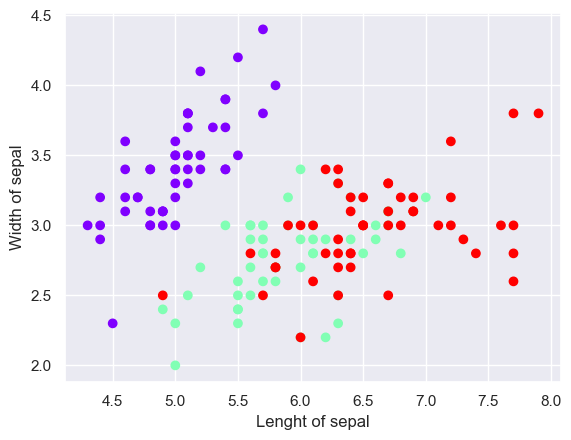

In [14]:
plt.scatter(raw_data['sepal_length'], raw_data['sepal_width'],c=raw_data['species'], cmap='rainbow')
plt.xlabel('Lenght of sepal')
plt.ylabel('Width of sepal')
plt.show()

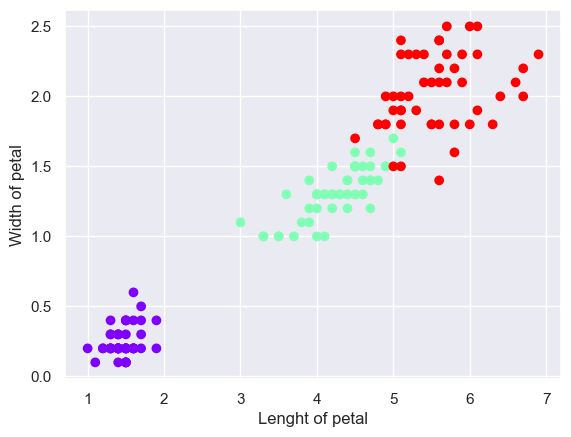

In [15]:
plt.scatter(raw_data['petal_length'], raw_data['petal_width'],c=raw_data['species'], cmap='rainbow')
plt.xlabel('Lenght of petal')
plt.ylabel('Width of petal')
plt.show()

# Cluster the data (unscaled)

In [16]:
x = raw_data.copy()
kmeans = KMeans(2)
kmeans.fit(x)
predicted_clusters = raw_data.copy()
predicted_clusters["Clusters"] = kmeans.fit_predict(x)
predicted_clusters

,sepal_length,sepal_width,petal_length,petal_width,species,Clusters
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,0
146,6.3,2.5,5.0,1.9,2,0
147,6.5,3.0,5.2,2.0,2,0
148,6.2,3.4,5.4,2.3,2,0


# Plot the clusters

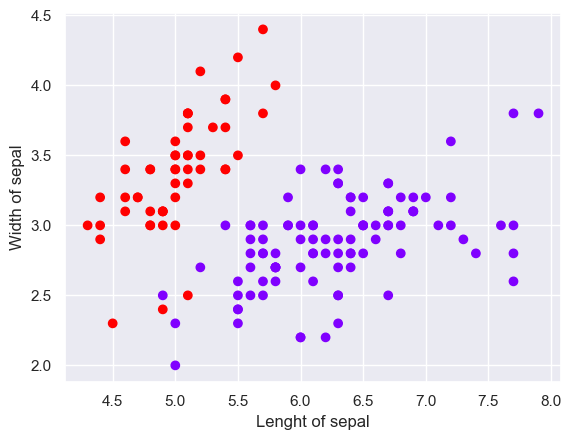

In [17]:
plt.scatter(predicted_clusters['sepal_length'], predicted_clusters['sepal_width'], c=predicted_clusters['Clusters'], cmap='rainbow')
plt.xlabel('Lenght of sepal')
plt.ylabel('Width of sepal')
plt.show()

# elbow method

In [19]:
un_scaled = raw_data.copy()
wcss = []
for i in range(1, 10):
    kmeans = KMeans(i)
    kmeans.fit(un_scaled)
    wcss.append(kmeans.inertia_)
wcss

[780.8244,
 179.26073390894817,
 87.35400000000001,
 67.8953612948628,
 79.06606323529412,
 46.04919710144929,
 39.372055852842806,
 31.148340301003348,
 29.35066101290015]

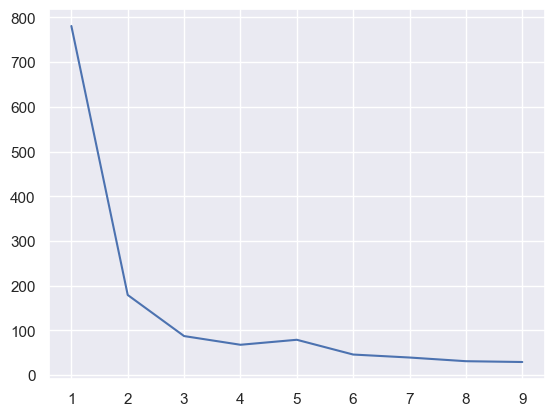

In [20]:
plt.plot(range(1, 10), wcss)
